In [1]:
import json
import pandas as pd
import numpy as np

In [2]:
with open("../data/processed/moves_with_coordinates.json") as f:
    moves = json.load(f)

df = pd.DataFrame(moves)
df.head()

,area,order,address,year,month,property_type,area_build_era,living_area_m2,estimated_value_low_kr,estimated_value_high_kr,source_url,latitude,longitude
0,Växjö,12,Wieselgrensgatan,2025,10.0,Villa,1930s and 1940s,172.0,2300000.0,3600000.0,https://www.hitta.se/omr%C3%A5de/56.8805:14.79...,56.880500,14.790417
1,Växjö,11,Långa gatan,2025,9.0,Apartment building (multi-family),2000s,NaN,NaN,NaN,https://www.hitta.se/omr%C3%A5de/56.864655:14....,56.864655,14.797700
2,Växjö,10,Falkgatan,2024,10.0,Villa (built 1946),1930s and 1940s,225.0,5100000.0,7800000.0,https://www.hitta.se/omr%C3%A5de/56.883724:14....,56.883724,14.794808
3,Moheda,9,Östra Järnvägsgatan 13,2022,11.0,Villa (built 1910),1960s and 1970s,83.0,NaN,NaN,https://www.hitta.se/omr%C3%A5de/57.00584:14.5...,57.005840,14.577040
4,Ör,8,Ör 1,2021,12.0,Villa,1950s and 1960s,87.0,NaN,NaN,https://www.hitta.se/omr%C3%A5de/56.971306:14....,56.971306,14.712307


In [3]:
df = df.sort_values("order").reset_index(drop=True)
df[["order", "address", "area", "year", "month"]]

,order,address,area,year,month
0,1,Bergsgatan,Moheda,2013,NaN
1,2,Östra Järnvägsgatan 15,Torpsbruk,2014,NaN
2,3,Kungsvägen 61,Växjö,2015,NaN
3,4,Östra Järnvägsgatan 15,Torpsbruk,2016,NaN
4,5,Härlöv 2,Härlöv,2017,NaN
5,6,Humlevägen,Torpsbruk,2018,10.0
6,7,Östra Järnvägsgatan 17,Moheda,2020,9.0
7,8,Ör 1,Ör,2021,12.0
8,9,Östra Järnvägsgatan 13,Moheda,2022,11.0
9,10,Falkgatan,Växjö,2024,10.0


In [4]:
df["month"] = df["month"].fillna(7)

df["move_date"] = pd.to_datetime(
    dict(year=df.year, month=df.month, day=1)
)

df[["order", "address", "move_date"]]

,order,address,move_date
0,1,Bergsgatan,2013-07-01
1,2,Östra Järnvägsgatan 15,2014-07-01
2,3,Kungsvägen 61,2015-07-01
3,4,Östra Järnvägsgatan 15,2016-07-01
4,5,Härlöv 2,2017-07-01
5,6,Humlevägen,2018-10-01
6,7,Östra Järnvägsgatan 17,2020-09-01
7,8,Ör 1,2021-12-01
8,9,Östra Järnvägsgatan 13,2022-11-01
9,10,Falkgatan,2024-10-01


In [5]:
df["months_since_previous_move"] = (
    df["move_date"].diff().dt.days / 30
)

df[["address", "months_since_previous_move"]]

,address,months_since_previous_move
0,Bergsgatan,NaN
1,Östra Järnvägsgatan 15,12.166667
2,Kungsvägen 61,12.166667
3,Östra Järnvägsgatan 15,12.200000
4,Härlöv 2,12.166667
5,Humlevägen,15.233333
6,Östra Järnvägsgatan 17,23.366667
7,Ör 1,15.200000
8,Östra Järnvägsgatan 13,11.166667
9,Falkgatan,23.333333


In [6]:
df["estimated_value_mid_kr"] = (
    df["estimated_value_low_kr"] +
    df["estimated_value_high_kr"]
) / 2

In [7]:
import math

def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate distance between two coordinates in kilometers.
    """
    R = 6371  # Earth radius in km
    
    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    )

    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c

In [8]:
distances = [None]

for i in range(1, len(df)):
    
    lat1 = df.loc[i-1, "latitude"]
    lon1 = df.loc[i-1, "longitude"]
    
    lat2 = df.loc[i, "latitude"]
    lon2 = df.loc[i, "longitude"]
    
    d = haversine(lat1, lon1, lat2, lon2)
    
    distances.append(d)

df["distance_from_previous_km"] = distances

df[["order", "address", "distance_from_previous_km"]]

,order,address,distance_from_previous_km
0,1,Bergsgatan,NaN
1,2,Östra Järnvägsgatan 15,3.240097
2,3,Kungsvägen 61,21.300860
3,4,Östra Järnvägsgatan 15,21.300860
4,5,Härlöv 2,9.295270
5,6,Humlevägen,8.917593
6,7,Östra Järnvägsgatan 17,2.453480
7,8,Ör 1,9.096212
8,9,Östra Järnvägsgatan 13,9.049550
9,10,Falkgatan,18.942723


<Axes: xlabel='distance_from_previous_km', ylabel='months_since_previous_move'>

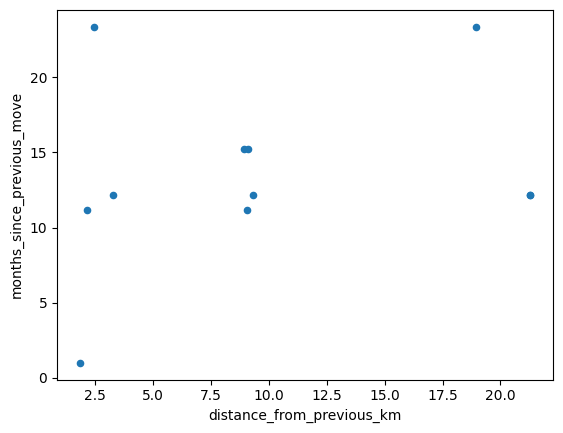

In [9]:
df.plot(
    x="distance_from_previous_km",
    y="months_since_previous_move",
    kind="scatter"
)

In [10]:
!pip install folium

In [11]:
import folium

In [12]:
center_lat = df["latitude"].mean()
center_lon = df["longitude"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=10)
m

In [13]:
for _, row in df.iterrows():
    popup_text = (
        f"Order: {row['order']}<br>"
        f"Address: {row['address']}<br>"
        f"Area: {row['area']}<br>"
        f"Date: {row['move_date'].strftime('%Y-%m')}"
    )
    
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=popup_text,
        tooltip=f"{row['order']}: {row['address']}"
    ).add_to(m)

m

In [14]:
m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

for _, row in df.iterrows():
    popup_text = (
        f"Order: {row['order']}<br>"
        f"Address: {row['address']}<br>"
        f"Area: {row['area']}<br>"
        f"Date: {row['move_date'].strftime('%Y-%m')}"
    )
    
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=popup_text,
        tooltip=f"{row['order']}: {row['address']}"
    ).add_to(m)

coordinates = df[["latitude", "longitude"]].values.tolist()

folium.PolyLine(
    coordinates,
    color="blue",
    weight=3,
    opacity=0.7
).add_to(m)

m

In [15]:
m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

for _, row in df.iterrows():
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=(
            f"Order: {row['order']}<br>"
            f"Address: {row['address']}<br>"
            f"Area: {row['area']}<br>"
            f"Date: {row['move_date'].strftime('%Y-%m')}"
        ),
        tooltip=f"{row['order']}: {row['address']}",
        icon=folium.DivIcon(
            html=f"""
            <div style="font-size: 12pt; color: black; font-weight: bold">
                {row['order']}
            </div>
            """
        )
    ).add_to(m)

folium.PolyLine(
    df[["latitude", "longitude"]].values.tolist(),
    color="blue",
    weight=3,
    opacity=0.7
).add_to(m)

m

In [16]:
m.save("../data/processed/move_history_map.html")

In [17]:
df["months_until_next_move"] = df["months_since_previous_move"].shift(-1)
df

,area,order,address,year,month,property_type,area_build_era,living_area_m2,estimated_value_low_kr,estimated_value_high_kr,source_url,latitude,longitude,move_date,months_since_previous_move,estimated_value_mid_kr,distance_from_previous_km,months_until_next_move
0,Moheda,1,Bergsgatan,2013,7.0,Villa (built 1957),1960s and 1970s,105.0,1300000.0,2200000.0,https://www.hitta.se/omr%C3%A5de/57.005165:14....,57.005165,14.580551,2013-07-01,NaN,1750000.0,NaN,12.166667
1,Torpsbruk,2,Östra Järnvägsgatan 15,2014,7.0,Villa (built 1933),1930s and 1950s,105.0,NaN,NaN,https://www.hitta.se/omr%C3%A5de/57.034237:14....,57.034237,14.576926,2014-07-01,12.166667,NaN,3.240097,12.166667
2,Växjö,3,Kungsvägen 61,2015,7.0,Apartment building (multi-family),1960s and 1990s,NaN,NaN,NaN,https://www.hitta.se/omr%C3%A5de/56.888546:14....,56.888546,14.805063,2015-07-01,12.166667,NaN,21.300860,12.200000
3,Torpsbruk,4,Östra Järnvägsgatan 15,2016,7.0,Villa (built 1933),1930s and 1950s,105.0,NaN,NaN,https://www.hitta.se/omr%C3%A5de/57.034237:14....,57.034237,14.576926,2016-07-01,12.200000,NaN,21.300860,12.166667
4,Härlöv,5,Härlöv 2,2017,7.0,NaN,1930s and 1940s,NaN,NaN,NaN,https://www.hitta.se/omr%C3%A5de/56.95712:14.6...,56.957120,14.636159,2017-07-01,12.166667,NaN,9.295270,15.233333
5,Torpsbruk,6,Humlevägen,2018,10.0,Villa (built 1981),1970s and 1980s,158.0,NaN,NaN,https://www.hitta.se/omr%C3%A5de/57.0285:14.56...,57.028500,14.569046,2018-10-01,15.233333,NaN,8.917593,23.366667
6,Moheda,7,Östra Järnvägsgatan 17,2020,9.0,Villa (built 1947),1950s and 1960s,120.0,NaN,NaN,https://www.hitta.se/omr%C3%A5de/57.006874:14....,57.006874,14.577088,2020-09-01,23.366667,NaN,2.453480,15.200000
7,Ör,8,Ör 1,2021,12.0,Villa,1950s and 1960s,87.0,NaN,NaN,https://www.hitta.se/omr%C3%A5de/56.971306:14....,56.971306,14.712307,2021-12-01,15.200000,NaN,9.096212,11.166667
8,Moheda,9,Östra Järnvägsgatan 13,2022,11.0,Villa (built 1910),1960s and 1970s,83.0,NaN,NaN,https://www.hitta.se/omr%C3%A5de/57.00584:14.5...,57.005840,14.577040,2022-11-01,11.166667,NaN,9.049550,23.333333
9,Växjö,10,Falkgatan,2024,10.0,Villa (built 1946),1930s and 1940s,225.0,5100000.0,7800000.0,https://www.hitta.se/omr%C3%A5de/56.883724:14....,56.883724,14.794808,2024-10-01,23.333333,6450000.0,18.942723,11.166667


In [20]:
train_df = df.dropna(subset=["months_until_next_move"])

In [21]:
features = [
    "distance_from_previous_km",
    "living_area_m2",
    "estimated_value_mid_kr"
]

X = train_df[features].fillna(0)
y = train_df["months_until_next_move"]

In [22]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

regressor.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
pd.DataFrame({
    "feature": features,
    "coefficient": regressor.coef_
})

,feature,coefficient
0,distance_from_previous_km,0.156660
1,living_area_m2,0.066592
2,estimated_value_mid_kr,-0.000002


In [24]:
latest_home = df.iloc[-1]

X_next = pd.DataFrame([[
    latest_home["distance_from_previous_km"],
    latest_home["living_area_m2"],
    latest_home["estimated_value_mid_kr"]
]], columns=features)

predicted_months = regressor.predict(X_next)

predicted_months

array([12.97977669])

In [25]:
df["next_latitude"] = df["latitude"].shift(-1)
df["next_longitude"] = df["longitude"].shift(-1)

df[["order","latitude","next_latitude","longitude","next_longitude"]]

,order,latitude,next_latitude,longitude,next_longitude
0,1,57.005165,57.034237,14.580551,14.576926
1,2,57.034237,56.888546,14.576926,14.805063
2,3,56.888546,57.034237,14.805063,14.576926
3,4,57.034237,56.957120,14.576926,14.636159
4,5,56.957120,57.028500,14.636159,14.569046
5,6,57.028500,57.006874,14.569046,14.577088
6,7,57.006874,56.971306,14.577088,14.712307
7,8,56.971306,57.005840,14.712307,14.577040
8,9,57.005840,56.883724,14.577040,14.794808
9,10,56.883724,56.864655,14.794808,14.797700


In [26]:
train_df = df.dropna(subset=["next_latitude", "next_longitude"])

In [27]:
features = [
    "latitude",
    "longitude",
    "distance_from_previous_km",
    "living_area_m2",
    "estimated_value_mid_kr"
]

X = train_df[features].fillna(0)

y_lat = train_df["next_latitude"]
y_lon = train_df["next_longitude"]

In [28]:
from sklearn.linear_model import LinearRegression

lat_model = LinearRegression()
lon_model = LinearRegression()

lat_model.fit(X, y_lat)
lon_model.fit(X, y_lon)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
latest = df.iloc[-1]

X_next = pd.DataFrame([[
    latest["latitude"],
    latest["longitude"],
    latest["distance_from_previous_km"],
    latest["living_area_m2"],
    latest["estimated_value_mid_kr"]
]], columns=features)

pred_lat = lat_model.predict(X_next)[0]
pred_lon = lon_model.predict(X_next)[0]

pred_lat, pred_lon

(np.float64(56.867993254013086), np.float64(14.823492950859844))

In [30]:
folium.Marker(
    location=[pred_lat, pred_lon],
    popup="Predicted next move",
    tooltip="Predicted move",
    icon=folium.Icon(color="red")
).add_to(m)

m